# 06 - Visualization

Turns the baseline layer x region accuracy table into a heatmap, to
answer Q2: does AlexNet's layer hierarchy mirror the brain's visual
hierarchy?

In [1]:
!git clone https://github.com/sossyh/ffa-dnn-ablation.git
%cd ffa-dnn-ablation

Cloning into 'ffa-dnn-ablation'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 98 (delta 51), reused 60 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (98/98), 33.19 KiB | 3.32 MiB/s, done.
Resolving deltas: 100% (51/51), done.
/content/ffa-dnn-ablation


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_df = pd.read_csv("results/tables/alexnet/baseline_accuracy.csv")
results_df.head()

,layer,region,accuracy
0,conv1,V1,0.031182
1,conv1,V2,0.029457
2,conv1,V3,0.019530
3,conv1,V4,0.027237
4,conv1,LOC,0.012907


## Reshape into a layer x region matrix

Layers are ordered early to late (conv1 -> fc8) and regions are ordered
roughly early visual cortex to higher-level cortex, so any hierarchy
pattern is easy to see visually.

In [3]:
layer_order = ["conv1", "conv2", "conv3", "conv4", "conv5", "fc6", "fc7", "fc8"]
region_order = ["V1", "V2", "V3", "V4", "LOC", "EBA", "FFA", "STS", "PPA"]

pivot = results_df.pivot(index="layer", columns="region", values="accuracy")
pivot = pivot.reindex(index=layer_order, columns=region_order)
pivot

region,V1,V2,V3,V4,LOC,EBA,FFA,STS,PPA
layer,,,,,,,,,
conv1,0.031182,0.029457,0.019530,0.027237,0.012907,0.011676,0.007147,-0.004124,0.018067
conv2,0.061705,0.066639,0.051176,0.040482,0.045233,0.048375,0.036512,0.017868,0.036439
conv3,0.067108,0.073124,0.074089,0.054186,0.081160,0.085375,0.060548,0.028609,0.053828
conv4,0.095549,0.107982,0.100677,0.086857,0.105173,0.114502,0.094264,0.045158,0.081498
conv5,0.111083,0.125449,0.118486,0.113186,0.112813,0.111544,0.111874,0.047078,0.089149
fc6,0.086425,0.103093,0.094972,0.090221,0.095070,0.101642,0.097012,0.032509,0.077448
fc7,0.099493,0.111459,0.109847,0.117845,0.129725,0.131797,0.129835,0.050053,0.115334
fc8,0.057792,0.088677,0.093600,0.099983,0.128304,0.127562,0.123291,0.063669,0.111756


## Heatmap

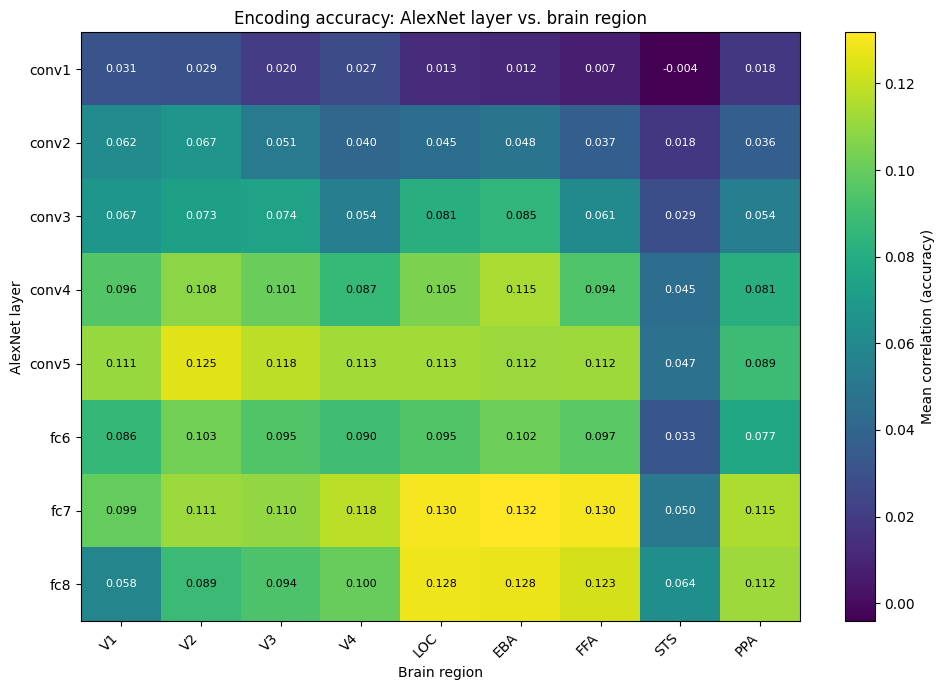

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")

ax.set_xticks(range(len(region_order)))
ax.set_xticklabels(region_order, rotation=45, ha="right")
ax.set_yticks(range(len(layer_order)))
ax.set_yticklabels(layer_order)

ax.set_xlabel("Brain region")
ax.set_ylabel("AlexNet layer")
ax.set_title("Encoding accuracy: AlexNet layer vs. brain region")

for i in range(len(layer_order)):
    for j in range(len(region_order)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                color="white" if val < pivot.values.max() * 0.6 else "black",
                fontsize=8)

fig.colorbar(im, ax=ax, label="Mean correlation (accuracy)")
fig.tight_layout()

import os
os.makedirs("results/figures/alexnet", exist_ok=True)
fig.savefig("results/figures/alexnet/layer_region_heatmap.png", dpi=150)

plt.show()

## Best layer per region

For each region, which layer predicts it best? This is the clearest
single summary of whether the hierarchy pattern holds.

In [5]:
best_layer_per_region = pivot.idxmax(axis=0)
best_accuracy_per_region = pivot.max(axis=0)

summary = pd.DataFrame({
    "best_layer": best_layer_per_region,
    "best_accuracy": best_accuracy_per_region,
})
summary = summary.reindex(region_order)
print(summary)

summary.to_csv("results/tables/alexnet/best_layer_per_region.csv")

       best_layer  best_accuracy
region                          
V1          conv5       0.111083
V2          conv5       0.125449
V3          conv5       0.118486
V4            fc7       0.117845
LOC           fc7       0.129725
EBA           fc7       0.131797
FFA           fc7       0.129835
STS           fc8       0.063669
PPA           fc7       0.115334


In [7]:
from google.colab import files

files.download("results/figures/alexnet/layer_region_heatmap.png")
files.download("results/tables/alexnet/best_layer_per_region.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>